In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from power_control import objective_function_maxsum
from power_control import power_control_dpc, power_control_with_maxsum, power_control_with_maxprod, graf_sinr_and_power, analysis

# Exercise 10

In [6]:
sinr, power = power_control_dpc(scenario_type = "default", target_sinr=0.5, pmax=1, pmin=0, number_of_iterations=20)

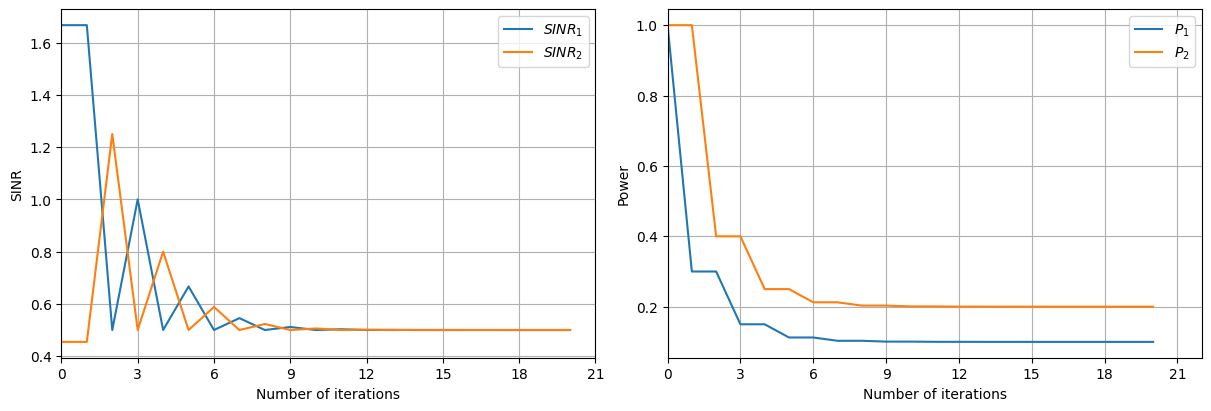

In [7]:
graf_sinr_and_power(number_ue = 2, value_sinr=sinr, value_power=power)

In [8]:
analysis(scenario_type="default", power=power[-1])


Power for UE 1: 0.1000 W
SINR for UE 1:  0.50
Channel Capacity for UE 1: 58.50 Mbps

Power for UE 2: 0.2000 W
SINR for UE 2:  0.50
Channel Capacity for UE 2: 58.50 Mbps

Sum Capacity: 116.99 Mbps
Energy Efficiency: 389.97 Mbits/J


# Exercise 11

## No power control

In [5]:
print("No power control - Noise-limited scenario")
analysis(scenario_type="Noise-limited", power=[1]*4)

No power control - Noise-limited scenario

Power for UE 1: 1.0000 W
SINR for UE 1:  4.57
Channel Capacity for UE 1: 247.84 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.01
Channel Capacity for UE 2: 1.11 Mbps

Power for UE 3: 1.0000 W
SINR for UE 3:  0.80
Channel Capacity for UE 3: 85.14 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  0.01
Channel Capacity for UE 4: 1.32 Mbps

Sum Capacity: 335.40 Mbps
Energy Efficiency: 83.85 Mbits/J


In [6]:
print("No power control - Interference-limited scenario")
analysis(scenario_type="Interference-limited", power=[1]*4)

No power control - Interference-limited scenario

Power for UE 1: 1.0000 W
SINR for UE 1:  92.69
Channel Capacity for UE 1: 654.98 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.01
Channel Capacity for UE 2: 1.34 Mbps

Power for UE 3: 1.0000 W
SINR for UE 3:  89.21
Channel Capacity for UE 3: 649.52 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  7.69
Channel Capacity for UE 4: 311.86 Mbps

Sum Capacity: 1617.70 Mbps
Energy Efficiency: 404.42 Mbits/J


## Power control with DPC

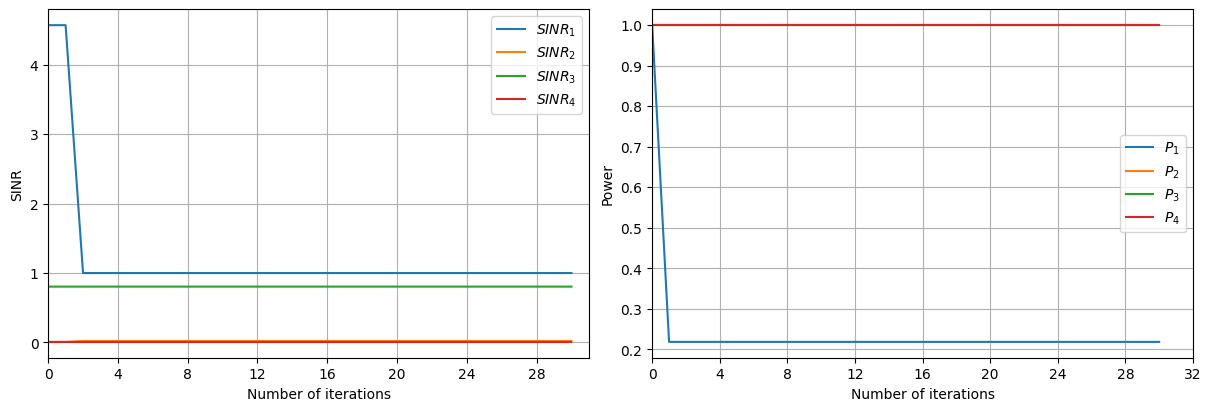

In [7]:
sinr_nl, power_nl = power_control_dpc(scenario_type="Noise-limited", target_sinr=1, pmax=1, pmin=1e-3, number_of_iterations = 30)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_nl, value_power=power_nl)

In [8]:
print("Power control - Noise-limited scenario")
analysis(scenario_type="Noise-limited", power=power_nl[-1])

Power control - Noise-limited scenario

Power for UE 1: 0.2187 W
SINR for UE 1:  1.00
Channel Capacity for UE 1: 100.00 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.02
Channel Capacity for UE 2: 3.11 Mbps

Power for UE 3: 1.0000 W
SINR for UE 3:  0.80
Channel Capacity for UE 3: 85.14 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  0.01
Channel Capacity for UE 4: 1.32 Mbps

Sum Capacity: 189.56 Mbps
Energy Efficiency: 58.89 Mbits/J


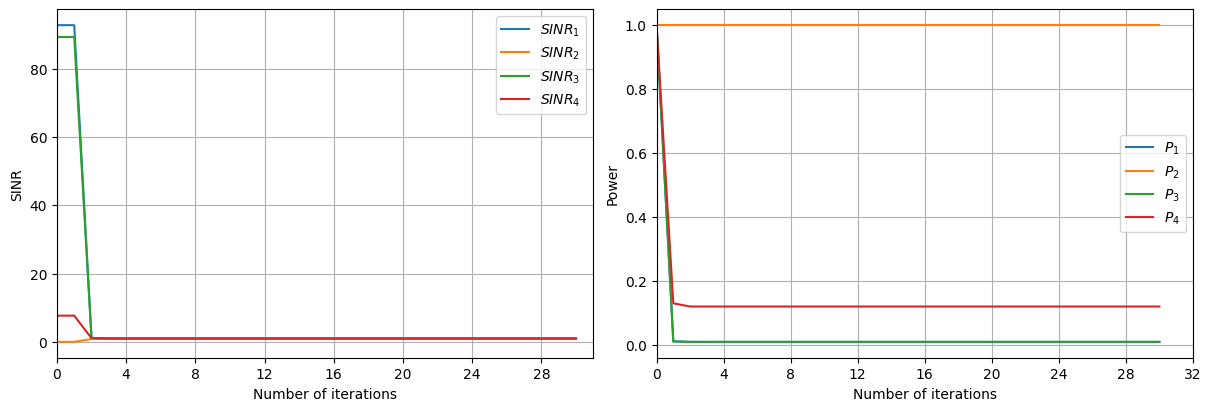

In [9]:
sinr_il, power_il = power_control_dpc(scenario_type="Interference-limited", target_sinr=1, pmax=1, pmin=1e-3, number_of_iterations = 30)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

In [10]:
print("Power control - Interference-limited scenario")
analysis(scenario_type="Interference-limited", power=power_il[-1])

Power control - Interference-limited scenario

Power for UE 1: 0.0095 W
SINR for UE 1:  1.00
Channel Capacity for UE 1: 100.00 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.96
Channel Capacity for UE 2: 97.29 Mbps

Power for UE 3: 0.0095 W
SINR for UE 3:  1.00
Channel Capacity for UE 3: 100.00 Mbps

Power for UE 4: 0.1201 W
SINR for UE 4:  1.00
Channel Capacity for UE 4: 100.00 Mbps

Sum Capacity: 397.29 Mbps
Energy Efficiency: 348.80 Mbits/J


# Exercise 12

In [42]:
sinr, power = power_control_with_maxsum(scenario_type = "default", pmax=1, pmin=1e-3, number_of_iterations=20, mu=1e-2, initial_power=0.5)

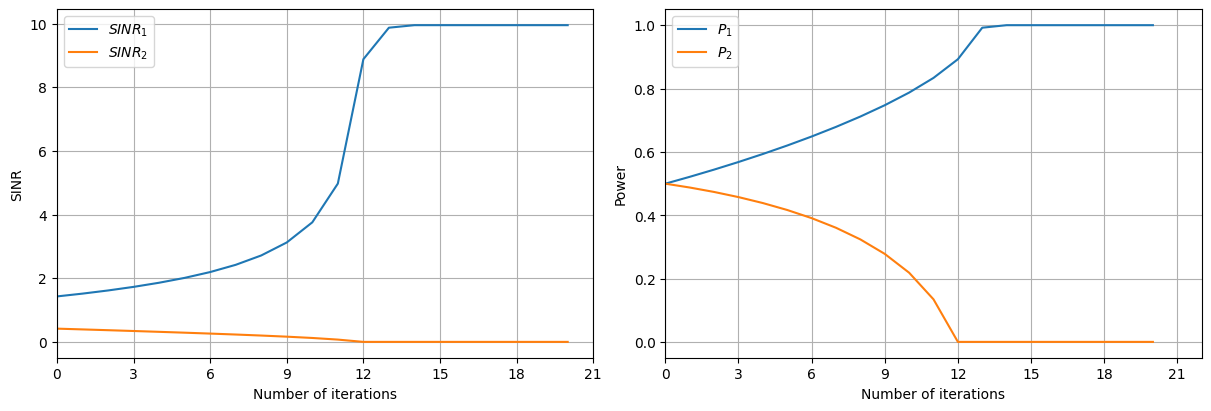

In [43]:
graf_sinr_and_power(number_ue = 2, value_sinr=sinr, value_power=power)

In [36]:
analysis(scenario_type="default", power=power[-1])


Power for UE 1: 1.0000 W
SINR for UE 1:  9.95
Channel Capacity for UE 1: 345.29 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.00
Channel Capacity for UE 2: 0.07 Mbps

Sum Capacity: 345.35 Mbps
Energy Efficiency: 345.01 Mbits/J


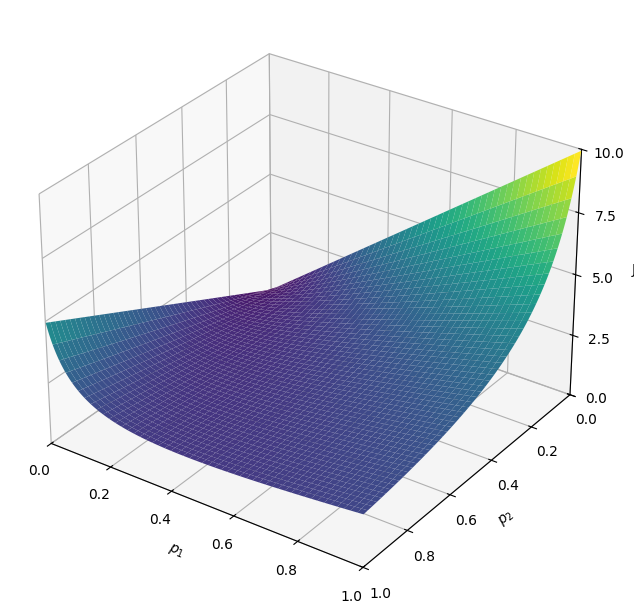

In [44]:
p_vals = np.linspace(0.001, 1, 1000)
power1, power2 = np.meshgrid(p_vals, p_vals)
Z = np.array([[objective_function_maxsum(scenario_type="default", power=[p1, p2]) for p1, p2 in zip(row1, row2)] for row1, row2 in zip(power1, power2)])

fig = plt.figure(figsize=(6,6), constrained_layout=True)
graf = fig.add_subplot(111, projection='3d')
graf.plot_surface(power1, power2, Z, cmap='viridis')
graf.set(xlabel=r"$p_1$", ylabel=r"$p_2$", zlabel="J")
graf.set(xlim=(1, 0), ylim=(0, 1), zlim=(0, 10))
graf.set(xticks=np.linspace(1,0,6), yticks=np.linspace(0,1,6), zticks=np.linspace(0,10,5))
graf.view_init(elev=30, azim=125)

plt.show()

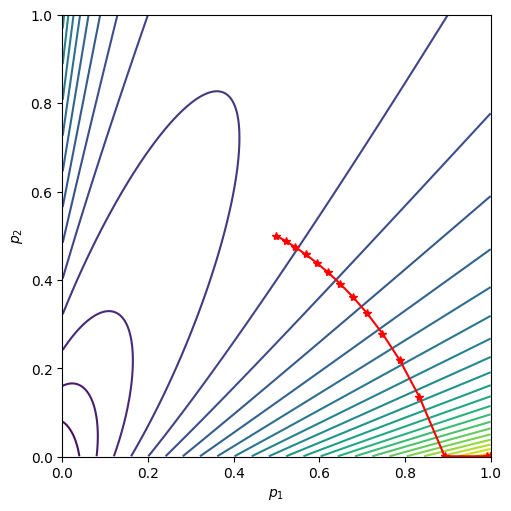

In [47]:
fig, graf = plt.subplots(figsize=(5, 5), constrained_layout=True)
graf.contour(power1, power2, Z, levels=30, cmap='viridis')
graf.plot(power[:, 0], power[:, 1], 'r-*')
graf.set(xlim=(0, 1), ylim=(0, 1), xlabel=r"$p_1$", ylabel=r"$p_2$", title="")
plt.show()

# Exercise 13

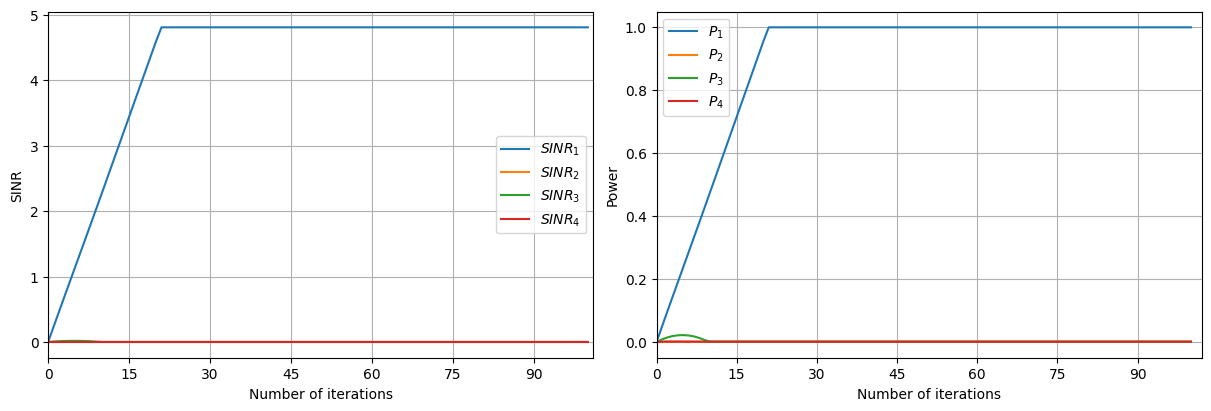

In [15]:
sinr_nl, power_nl = power_control_with_maxsum(scenario_type="Noise-limited", pmax=1, pmin=1e-3, number_of_iterations = 100, mu=1e-2, initial_power=0)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_nl, value_power=power_nl)

In [16]:
print("Power control - Noise-limited scenario")
analysis(scenario_type="Noise-limited", power=power_nl[-1])

Power control - Noise-limited scenario

Power for UE 1: 1.0000 W
SINR for UE 1:  4.81
Channel Capacity for UE 1: 253.84 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.00
Channel Capacity for UE 2: 0.00 Mbps

Power for UE 3: 0.0010 W
SINR for UE 3:  0.00
Channel Capacity for UE 3: 0.12 Mbps

Power for UE 4: 0.0010 W
SINR for UE 4:  0.00
Channel Capacity for UE 4: 0.00 Mbps

Sum Capacity: 253.96 Mbps
Energy Efficiency: 253.20 Mbits/J


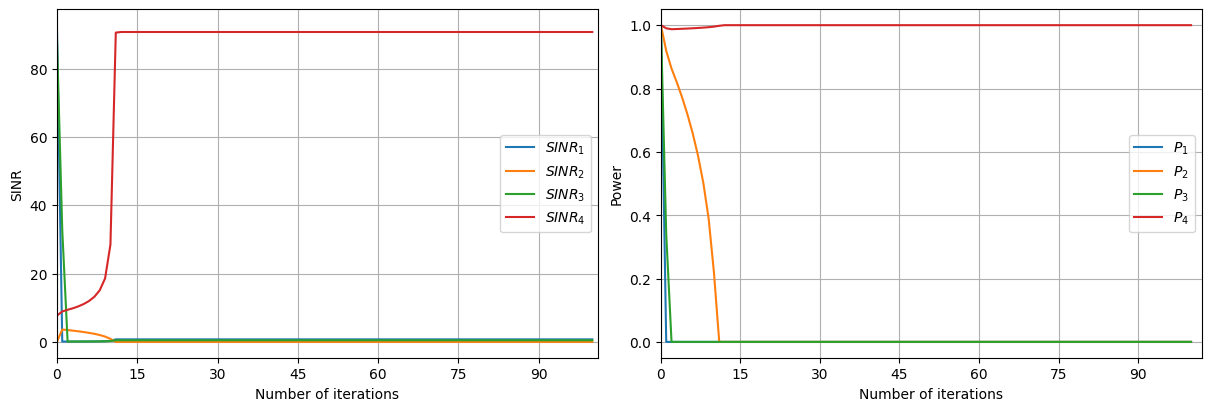

In [17]:
sinr_il, power_il = power_control_with_maxsum(scenario_type="Interference-limited", pmax=1, pmin=1e-3, number_of_iterations = 100, mu=1e-4, initial_power=1)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

In [18]:
print("Power control - Interference-limited scenario")
analysis(scenario_type="Interference-limited", power=power_il[-1])

Power control - Interference-limited scenario

Power for UE 1: 0.0010 W
SINR for UE 1:  0.74
Channel Capacity for UE 1: 80.18 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.00
Channel Capacity for UE 2: 0.57 Mbps

Power for UE 3: 0.0010 W
SINR for UE 3:  0.48
Channel Capacity for UE 3: 56.26 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  90.69
Channel Capacity for UE 4: 651.87 Mbps

Sum Capacity: 788.89 Mbps
Energy Efficiency: 786.53 Mbits/J


# Exercise 14

In [19]:
sinr, power = power_control_with_maxprod(scenario_type = "default", pmax=1, pmin=1e-3, number_of_iterations=1000, mu=1e-2, initial_power=0.1)

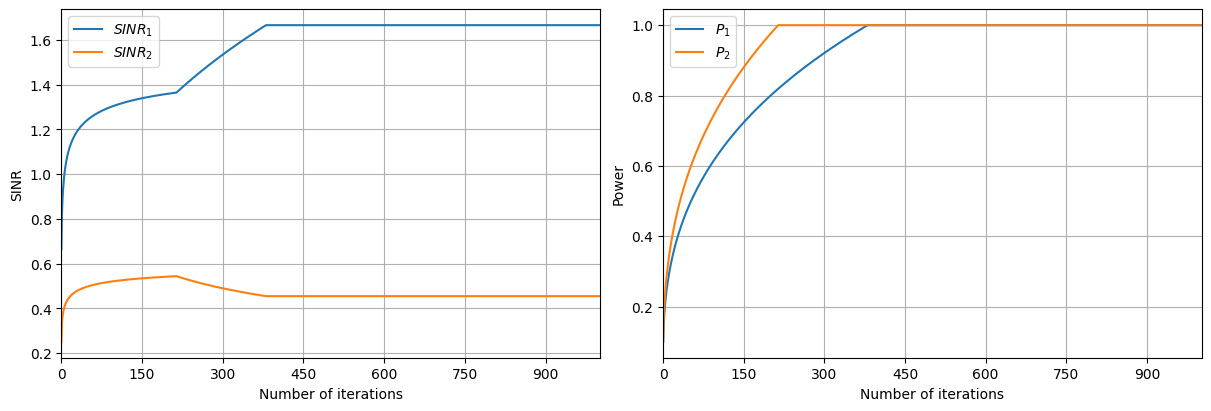

In [20]:
graf_sinr_and_power(number_ue = 2, value_sinr=sinr, value_power=power)

In [21]:
analysis(scenario_type="default", power=power[-1])


Power for UE 1: 1.0000 W
SINR for UE 1:  1.67
Channel Capacity for UE 1: 141.50 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.45
Channel Capacity for UE 2: 54.06 Mbps

Sum Capacity: 195.56 Mbps
Energy Efficiency: 97.78 Mbits/J


# Exercise 15

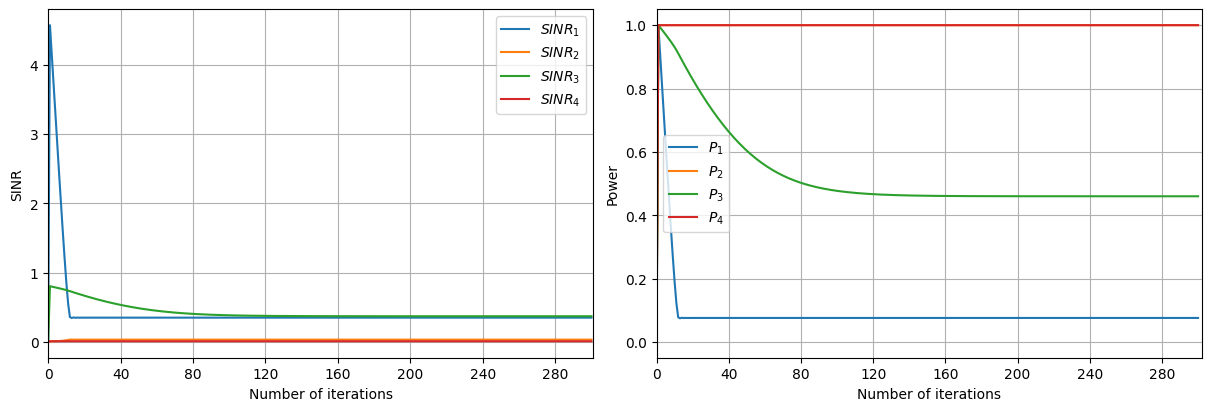

In [22]:
sinr_nl, power_nl = power_control_with_maxprod(scenario_type="Noise-limited", pmax=1, pmin=1e-3, number_of_iterations = 300, mu=1e-2, initial_power=1e-3)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_nl, value_power=power_nl)

In [23]:
print("Power control - Noise-limited scenario")
analysis(scenario_type="Noise-limited", power=power_nl[-1])

Power control - Noise-limited scenario

Power for UE 1: 0.0765 W
SINR for UE 1:  0.35
Channel Capacity for UE 1: 43.29 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.03
Channel Capacity for UE 2: 4.63 Mbps

Power for UE 3: 0.4603 W
SINR for UE 3:  0.37
Channel Capacity for UE 3: 45.43 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  0.01
Channel Capacity for UE 4: 1.32 Mbps

Sum Capacity: 94.67 Mbps
Energy Efficiency: 37.32 Mbits/J


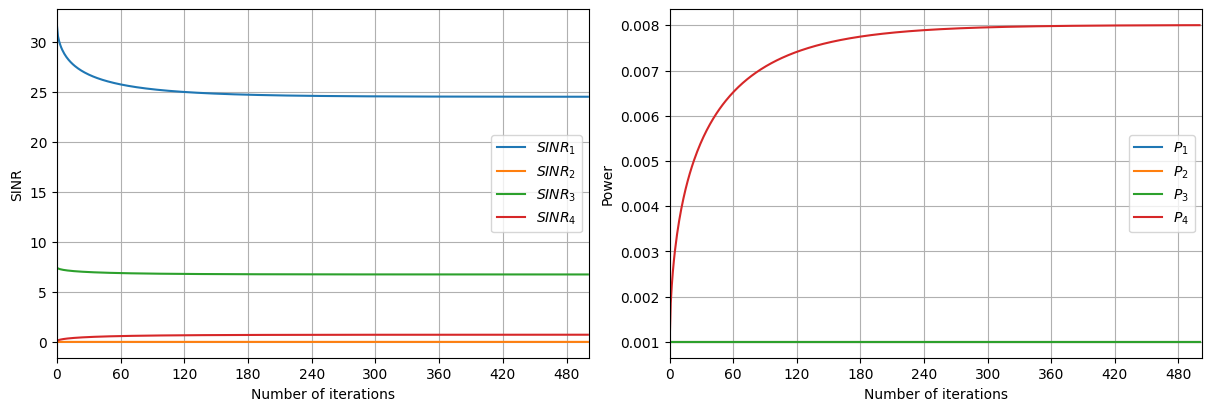

In [29]:
sinr_il, power_il = power_control_with_maxprod(scenario_type="Interference-limited", pmax=1, pmin=1e-3, number_of_iterations = 500, mu=1e-6, initial_power=1e-3)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

In [30]:
print("Power control - Interference-limited scenario")
analysis(scenario_type="Interference-limited", power=power_il[-1])

Power control - Interference-limited scenario

Power for UE 1: 0.0010 W
SINR for UE 1:  24.53
Channel Capacity for UE 1: 467.40 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.01
Channel Capacity for UE 2: 1.30 Mbps

Power for UE 3: 0.0010 W
SINR for UE 3:  6.75
Channel Capacity for UE 3: 295.48 Mbps

Power for UE 4: 0.0080 W
SINR for UE 4:  0.73
Channel Capacity for UE 4: 78.73 Mbps

Sum Capacity: 842.90 Mbps
Energy Efficiency: 76606.66 Mbits/J


Exercise 10 – Distributed Power Control (DPC)
Neste exercício, foi implementado o algoritmo DPC com alvo de SINR (
𝛾
=
0.5
γ=0.5). O sistema convergiu rapidamente, ajustando a potência dos UEs até atingir o alvo, com consumo de energia inferior ao caso sem controle. Houve melhoria na eficiência energética, mas a soma da capacidade foi limitada, refletindo o compromisso entre atingir o SINR alvo e manter a eficiência espectral.

Exercise 11 – DPC em cenários noise-limited e interference-limited
No cenário noise-limited, o controle de potência distribuiu melhor a potência, mas manteve alguns UEs com SINR muito baixo. Já no cenário interference-limited, o DPC conseguiu equalizar o SINR em torno do alvo para múltiplos UEs, reduzindo drasticamente a potência de UEs com boa qualidade de canal. Isso evidenciou a capacidade do DPC de mitigar interferência, mesmo em ambientes congestionados, com ganho significativo de eficiência energética.

Exercise 12 – Maximização da soma da capacidade (Max-Sum)
Aqui, a potência foi ajustada para maximizar a soma da capacidade. Observa-se que o algoritmo concentra potência nos UEs com melhores canais, aumentando significativamente a capacidade total, mas deixando UEs com piores condições quase sem serviço. É um comportamento típico do Max-Sum: otimizar o throughput total sacrificando fairness.

Exercise 13 – Max-Sum em cenários noise-limited e interference-limited
O padrão se manteve: no noise-limited, a potência foi quase toda direcionada para um único UE com melhor canal; no interference-limited, o algoritmo concentrou recursos nos UEs mais vantajosos, aumentando a soma da capacidade. A eficiência energética foi alta, mas a equidade entre UEs ficou comprometida.

Exercise 14 – Maximização do produto das capacidades (Max-Prod)
Com o objetivo de maximizar o produto das capacidades, o algoritmo buscou equilibrar throughput total e fairness. Houve redistribuição mais justa das potências entre os UEs, garantindo que todos tivessem capacidade mínima razoável, mas a soma da capacidade caiu em relação ao Max-Sum.

Exercise 15 – Max-Prod em cenários noise-limited e interference-limited
Nos dois cenários, o Max-Prod manteve valores mínimos de capacidade em todos os UEs, com destaque para o cenário interference-limited, onde a eficiência energética foi extremamente elevada. Este algoritmo se mostrou mais adequado para garantir fairness sem grandes perdas de eficiência.

Conclusão
DPC: ideal para manter SINR alvo, com bom compromisso entre consumo de potência e estabilidade do sistema.

Max-Sum: maximiza o throughput, mas compromete fairness, favorecendo apenas os UEs com melhor canal.

Max-Prod: apresenta melhor equilíbrio entre eficiência espectral e justiça entre os usuários, sendo mais adequado para cenários onde a equidade de serviço é prioritária.